# GaussED

In [1]:
import jax
from jax import config
import jax.numpy as jnp
from jax import Array
import numpy as np
config.update("jax_enable_x64", True)  # do this at the very top

import matplotlib.pyplot as plt

import mplcyberpunk
plt.style.use("cyberpunk")

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]  # matches LaTeX default


from gaussed.domains import Euclidean
from gaussed.domains.index import IndexDomain
from gaussed.codomains import Codomain

from gaussed.gp.gp_ops.base import KernelSpec, FunSpec
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.partial import Partial
from gaussed.gp.gp_ops.grad import Grad
from gaussed.gp.gp_ops.affine import Affine
from gaussed.gp.gp_ops.weighted_eval import WeightedEval
from gaussed.gp.gp_ops.probe import Probe, ProbeStack, as_stack
from gaussed.gp.gp_ops.linearise import Linearise

from gaussed.gp.kernels.rbf import RBFKernel, RBFParams
from gaussed.gp.kernels.matern import MaternKernel, MaternParams
from gaussed.gp.kernels.imq import IMQKernel, IMQParams
from gaussed.gp.kernels.delta import DeltaKernel, DeltaParams
from gaussed.gp.kernels.stacked import StackedKernel
from gaussed.gp.kernels.coregional import CoregionParams, CoregionalKernel
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP, PosteriorGP

from gaussed.model import GPModel
from gaussed.utils.shape_helpers import pack_ev2mat

from gaussed.backends.base import ExactBackend
from gaussed.backends.solvers.linear_solver import SolverFns
from gaussed.backends.solvers.cholesky import (
    chol_solve_hook,
    chol_sqrt_hook,
    chol_logdet_hook,
)
from gaussed.backends.solvers.svd import svd_solve_hook, svd_sqrt_hook, svd_logdet_hook

from gaussed.likelihoods.gaussian import GaussianLikelihood
from gaussed.likelihoods.gaussian_noise import DiagonalNoise
from gaussed.ed.base import *

solver_fns = SolverFns(svd_solve_hook(), svd_sqrt_hook(), svd_logdet_hook())


### GP Posterior

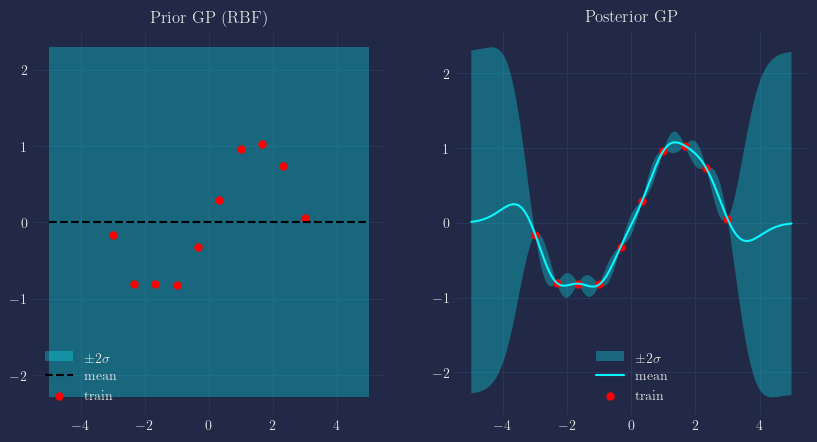

In [23]:
# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(0.), amplitude=jnp.array(1.0))
kernel   = RBFKernel(rbf_params)
backend = ExactBackend(solverfns=solver_fns) 

gp = GP(domain, codomain, mean, kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 10).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood()
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# plt.tight_layout()
plt.show()


### Partial Operator

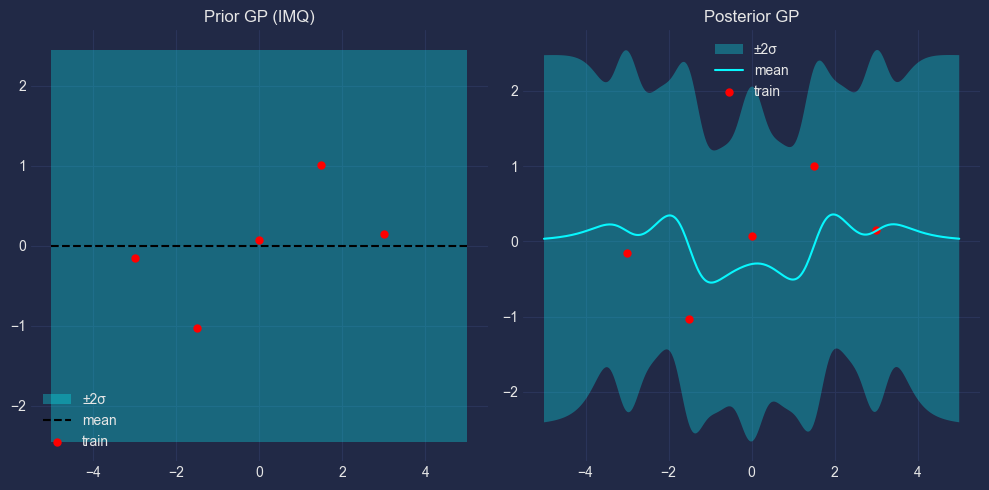

In [55]:

# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
imq_params = IMQParams(lengthscale=jnp.array(0.5), amplitude=jnp.array(1.24751754), beta=jnp.array(1.0))
imq_kernel   = IMQKernel(imq_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, imq_kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 5).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.04
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(Partial(0),), fnl=Eval(Xtr))
Xt = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01])))
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (IMQ)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


## Gradient Operator

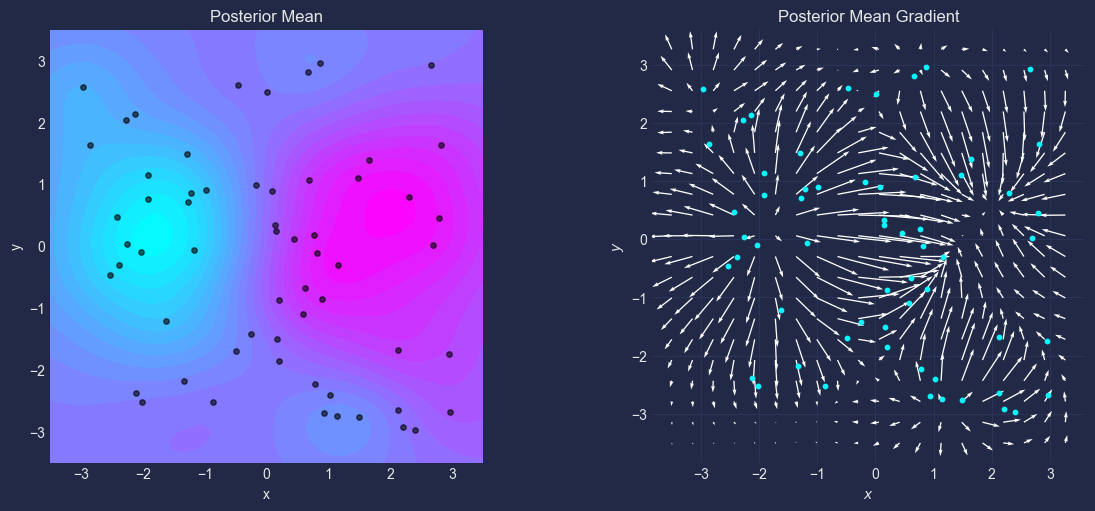

In [59]:
# ----------------------------
# GP prior (2D, with ARD)
# ----------------------------
domain   = Euclidean((2,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)

solver_fns = SolverFns(chol_solve_hook(), chol_sqrt_hook(), chol_logdet_hook())

backend = ExactBackend(solverfns=solver_fns)

# ARD lengthscales (ℓ_x, ℓ_y); amplitude = σ²
imq_params = IMQParams(
    lengthscale=jnp.array([1.0, 0.7]),  # ARD
    amplitude=jnp.array(1.0),
    beta=jnp.array(1.0),
)
kernel  = IMQKernel(imq_params)

gp      = GP(domain, codomain, mean, kernel, backend)

# ----------------------------
# Synthetic 2D data
# ----------------------------
key = jax.random.PRNGKey(0)
n_tr = 60
Xtr = jax.random.uniform(key, (n_tr, 2), minval=-3.0, maxval=3.0)

def f_true(xy: jnp.ndarray) -> jnp.ndarray:
    # smooth, non-separable target
    x, y = xy[..., 0], xy[..., 1]
    return jnp.sin(x) * jnp.cos(0.8 * y) + 0.2 * x

y_clean = jax.vmap(f_true)(Xtr)
noise   = 0.1
y       = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# ----------------------------
# Probes
# ----------------------------
Ftr   = Probe(ops=(), fnl=Eval(Xtr))                 # function values at Xtr
lik   = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01])))
model = GPModel(gp=gp, likelihood=lik)
post  = model.condition(Ftr, y)

# Test grid for visualisation
nx = ny = 60
x1 = jnp.linspace(-3.5, 3.5, nx)
x2 = jnp.linspace(-3.5, 3.5, ny)
Xg1, Xg2 = jnp.meshgrid(x1, x2, indexing="xy")
Xgrid = jnp.stack([Xg1.ravel(), Xg2.ravel()], axis=1)     # (nx*ny, 2)

F_eval  = Probe(ops=(), fnl=Eval(Xgrid))                  # function probe
F_grad  = Probe(ops=(Grad(), ), fnl=Eval(Xgrid))  # gradient probe (∂/∂x, ∂/∂y)

# Posterior mean and gradient mean
m_post_grid = post.mean(F_eval).reshape(nx*ny)            # (N,)
g_post_grid = post.mean(F_grad).reshape(nx*ny, 2)         # (N, 2)

# ----------------------------
# Autodiff cross-check of gradient
# ----------------------------
# Make a scalar-valued mean function m(x) using the same machinery,
# then compare ∇m(x) from autodiff with the Gradient probe output.
def mean_at(x_row: jnp.ndarray) -> jnp.ndarray:
    Fe = Probe(ops=(), fnl=Eval(x_row[None, :]))
    return post.mean(Fe).squeeze()                        # scalar

grad_mean_at = jax.jit(jax.grad(mean_at))                 # (2,) -> (2,)

# # Check on a small random subset to keep it snappy
# idx = jnp.arange(Xgrid.shape[0])[:: max(1, (nx*ny)//2000)]
# Xchk = Xgrid[idx]
# g_ad  = jax.vmap(grad_mean_at)(Xchk)                      # (M, 2)
# g_gp  = g_post_grid[idx]                                  # (M, 2)
# grad_max_err = jnp.max(jnp.abs(g_ad - g_gp))
# print("Max |∇ mean| error vs autodiff:", float(grad_max_err))

# ----------------------------
# Plotting (two separate figures)
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 1) Posterior mean as filled contours
ax = axes[0]
M = m_post_grid.reshape(ny, nx)
cf = ax.contourf(Xg1, Xg2, M, levels=25)
ax.scatter(np.array(Xtr[:, 0]), np.array(Xtr[:, 1]), s=15, c="k", alpha=0.6)
ax.set_title("Posterior Mean")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")

# 2) Gradient quiver (posterior mean gradient)
ax = axes[1]
G = g_post_grid.reshape(ny, nx, 2)
step = max(1, nx // 20)  # thin arrows for clarity
ax.quiver(
    Xg1[::step, ::step], Xg2[::step, ::step],
    G[::step, ::step, 0], G[::step, ::step, 1],
    angles="xy", scale_units="xy", scale=1.0, color='white'
)
ax.scatter(Xtr[:, 0], Xtr[:, 1], s=10)
ax.set_title("Posterior Mean Gradient")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal", adjustable="box")

plt.show()


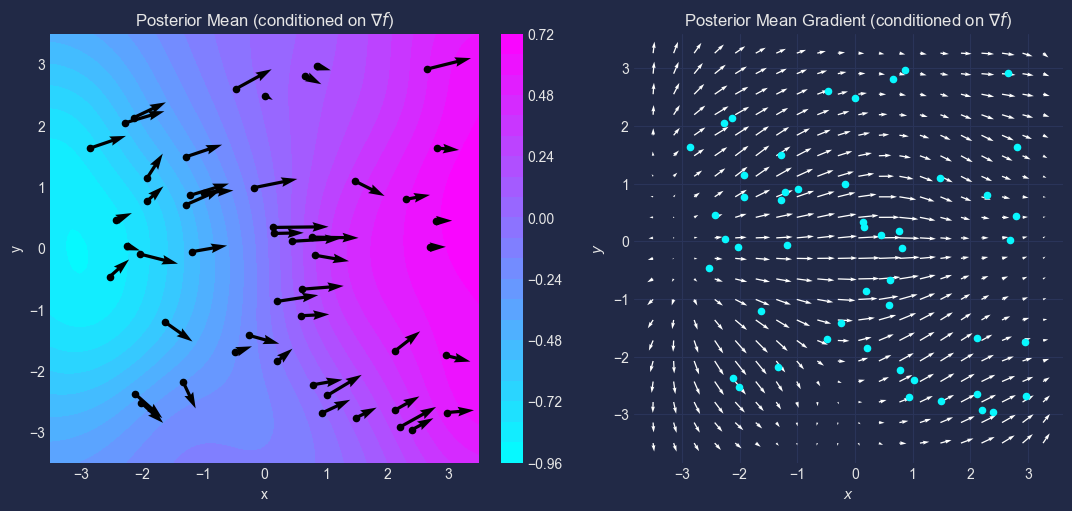

In [ ]:
# ----------------------------
# GP prior (2D, with ARD)
# ----------------------------
domain   = Euclidean((2,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)

solver_fns = SolverFns(svd_solve_hook(), svd_sqrt_hook(), svd_logdet_hook())
backend = ExactBackend(solverfns=solver_fns)

# ARD lengthscales (ℓ_x, ℓ_y); amplitude = σ²
imq_params = IMQParams(
    lengthscale=jnp.array([2., 1.9]),  # ARD
    amplitude=jnp.array(1.0),
    beta=jnp.array(0.01),
)
kernel  = IMQKernel(imq_params)
gp      = GP(domain, codomain, mean, kernel, backend)

# ----------------------------
# Synthetic 2D data
# ----------------------------
key = jax.random.PRNGKey(0)
n_tr = 50
Xtr = jax.random.uniform(key, (n_tr, 2), minval=-3.0, maxval=3.0)

def f_true(xy: jnp.ndarray) -> jnp.ndarray:
    x, y = xy[..., 0], xy[..., 1]
    return 0.2 * jnp.sin(x) * jnp.cos(0.8 * y) + 0.3 * x  # scalar

# --- gradient observations (condition on these!) ---
# g_true: (n_tr, 2) with columns [∂f/∂x, ∂f/∂y]
g_true = jax.vmap(jax.grad(f_true))(Xtr)

grad_noise = 0.1
key_g = jax.random.split(key, 2)[1]
g_obs = g_true + grad_noise * jax.random.normal(key_g, g_true.shape)  # (n_tr, 2)

# ----------------------------
# Probes (train on gradients)
# ----------------------------
# Gradient operator produces a 2-output (multioutput) GP at each location.
Ftr   = Probe(ops=(Grad(),), fnl=Eval(Xtr))        # gradient at Xtr, shape ~ (n_tr, 2)
# Per-output diagonal noise (broadcast across n_tr)
lik   = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01, 0.01])))
model = GPModel(gp=gp, likelihood=lik)

# Condition on gradient observations
post  = model.condition(Ftr, g_obs)

# grid for visualisation
nx = ny = 60
x1 = jnp.linspace(-3.5, 3.5, nx)
x2 = jnp.linspace(-3.5, 3.5, ny)
Xg1, Xg2 = jnp.meshgrid(x1, x2, indexing="xy")
Xgrid = jnp.stack([Xg1.ravel(), Xg2.ravel()], axis=1)     # (nx*ny, 2)

F_eval = Probe(ops=(),        fnl=Eval(Xgrid))            # function values
F_grad = Probe(ops=(Grad(),), fnl=Eval(Xgrid))            # gradient values

# Posterior means
m_post_grid = post.mean(F_eval).reshape(nx*ny)            # (N,)
g_post_grid = post.mean(F_grad).reshape(nx*ny, 2)         # (N,2)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 1) Posterior mean as filled contours
ax = axes[0]
M = np.array(m_post_grid).reshape(ny, nx)
cf = ax.contourf(np.array(Xg1), np.array(Xg2), M, levels=25)
ax.scatter(np.array(Xtr[:, 0]), np.array(Xtr[:, 1]), s=20, c="k", alpha=1.)

# overlay observed gradient arrows at training points
X = np.array(Xtr[:, 0])
Y = np.array(Xtr[:, 1])
U = np.array(g_obs[:, 0])   # ∂f/∂x
V = np.array(g_obs[:, 1])   # ∂f/∂y

ax.quiver(
    X, Y, U, V,
    angles="xy", scale_units="xy", scale=0.7,
    color="k",  zorder=3
)

ax.set_title("Posterior Mean (conditioned on $\\nabla f$)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal", adjustable="box")
fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

# 2) Gradient quiver (posterior mean gradient)
ax = axes[1]
G = np.array(g_post_grid).reshape(ny, nx, 2)
step = max(1, nx // 20)  # thin arrows for clarity
ax.quiver(
    np.array(Xg1[::step, ::step]), np.array(Xg2[::step, ::step]),
    G[::step, ::step, 0], G[::step, ::step, 1],
    angles="xy", scale_units="xy", scale=1.1, color='white'
)
ax.scatter(np.array(Xtr[:, 0]), np.array(Xtr[:, 1]), s=20, alpha=1.)
ax.set_title("Posterior Mean Gradient (conditioned on $\\nabla f$)")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_aspect("equal", adjustable="box")

plt.show()


### Multioutput GPs

#### Coregional (ICM) Kernels

$$ (f_1,\ldots, f_D)^\top \sim \mathcal{GP}(m, K), $$

where $K$ is a matrix-valued kernel:
$$ K:\mathcal{X}\times\mathcal{X} \rightarrow \mathbb{R}^{D\times D}. $$

Takes form:

$$ K(x,y) = \Sigma \, k(x,y). $$


#### Hard-coded

In [9]:
domain   = Euclidean((1,))
codomain = Codomain((2,))
mean     = ZeroMeanFun(domain, codomain)

# Kernel specification
imq_params = IMQParams(lengthscale=jnp.array(0.5), amplitude=jnp.array(1.24751754), beta=jnp.array(1.0))
imq_kernel = IMQKernel(imq_params)

coreg_par = CoregionParams(imq_params, L_params = jnp.array([[1.0, 0.8], [0.8, 1.0]]))
coreg_kernel = CoregionalKernel(imq_kernel, coreg_par)

backend = ExactBackend(solverfns=solver_fns)

# GP specification
gp = GP(domain, codomain, mean, coreg_kernel, backend)
gpmodel = GPModel(gp=gp, likelihood=lik)

ks = gp.kernel_spec()

This is a ICM kernel with (square-root) matrix:

In [10]:
mat = coreg_kernel._make_L()
mat

Array([[1.3132617, 0.       ],
       [0.8      , 1.3132617]], dtype=float64)

Let's look at an output:

In [11]:
x, y = jnp.array([[1.0], [2.0]])
coreg_kernel(x, y, domain)

Array([[[[1.00527746, 0.61238516],
         [0.61238516, 1.3783243 ]]]], dtype=float64)

#### Through GaussED Ops

Create an independent stack of GPs:

$$ K(x, y) = \begin{pmatrix} k_1(x,y) & 0 & \ldots & 0 \\ 0 & k_2(x,y) & \ldots & 0 \\ \vdots  & \vdots & \ddots & \vdots \\ 0 & 0 & \ldots & k_D(x,y) \end{pmatrix} $$

In [12]:
domain   = Euclidean((1,))
codomain = Codomain((2,))
mean     = ZeroMeanFun(domain, codomain)

stacked_kern = StackedKernel((imq_kernel, imq_kernel))

backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, stacked_kern, backend)
gpmodel = GPModel(gp=gp, likelihood=lik)

ks = gp.kernel_spec()

Let's create the operator:

In [13]:
aff_op = Affine(mat)                  # Affine operator f \mapsto A f + c
eval_op = Eval(x)                     # Evaluation operator
probe = Probe((aff_op,), eval_op)     # Probe composes them

In [14]:
eval_op_other = Eval(y)
probe_other = Probe((aff_op, ), eval_op_other)

probe.kernel(probe_other, ks, None)

Array([[[[1.00527746, 0.61238516],
         [0.61238516, 1.3783243 ]]]], dtype=float64)

### Probabilistic Linear Solvers 

Create linear system:

In [ ]:
def tridiag_laplacian_1d(n: int, kappa: float = 1.0) -> Array:
    main = (2.0 + kappa) * jnp.ones(n)
    off  = -1.0 * jnp.ones(n - 1)
    A = jnp.diag(main) + jnp.diag(off, 1) + jnp.diag(off, -1)
    return A

# Problem
N = 40
key = jax.random.PRNGKey(0)
key1, key2 = jax.random.split(key, 2)
A = jax.random.normal(key1, (N,N))
v_true = jax.random.normal(key2, (N,))
b = A @ v_true


#### Via Index Domain

In [16]:

index_domain = IndexDomain(N,  jnp.float64)

# Pick k directions: k standard basis columns
k = 20
idxs = jnp.linspace(0, N-1, k).round().astype(jnp.int32)
S = jnp.eye(N)[:, idxs]                               # (N,k)

# Build W and y
W = (S.T @ A)                                         # (k,N)  == S^T A
y = (S.T @ b).reshape(k, 1)                           # (k,1)

# GP prior on IndexDomain with delta kernel (Σ0 = α I)
index_domain = IndexDomain(N, jnp.float64)
codomain = Codomain((1,))
mean = ZeroMeanFun(index_domain, codomain)
delta_kernel = DeltaKernel(DeltaParams(amplitude=jnp.array(1.)))
backend = ExactBackend(solverfns=solver_fns)

gp = GP(index_domain, codomain, mean, delta_kernel, backend)
gpmodel = GPModel(gp=gp, likelihood=GaussianLikelihood())

# Observations via WeightedEval over all indices X_all
X_all = jnp.arange(N, dtype=jnp.int32).reshape(N, 1)
obs_fnl = WeightedEval(W=W, X=X_all)
probe_obs = Probe(ops=(), fnl=obs_fnl)
post = gpmodel.condition(probe_obs, y)                # posterior GP over v

# Evaluate posterior on all indices for plotting
probe_te = Probe(ops=(), fnl=Eval(X_all))
mu = post.mean(probe_te)                      # mu: (N,1), cov: (N,1,N,1) (or your backend shape)
C = post.covariance(probe_te)

mu1 = mu

##### Plot Output

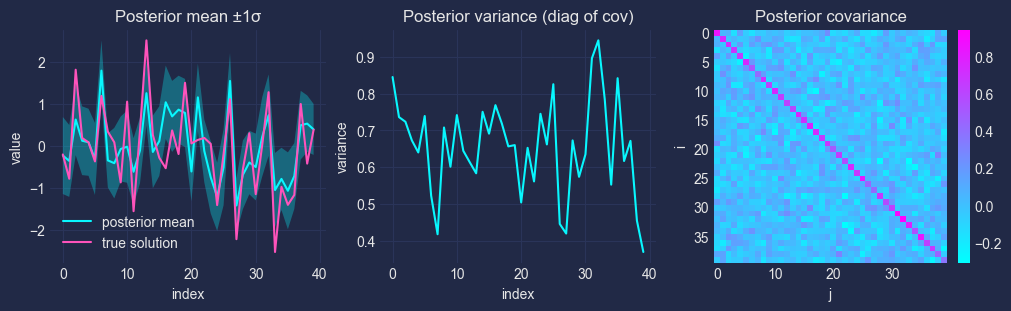

In [17]:
# X (indices), mean, covariance -> 1D arrays / NxN
x = jnp.asarray(X_all).squeeze()
if x.ndim != 1:
    x = jnp.arange(jnp.asarray(mu).shape[0])
var  = jnp.diag(C)
std  = jnp.sqrt(jnp.clip(var, 0.0, jnp.inf))
vt   = v_true

fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)

# 1) Mean ±1σ (and truth if provided)
ax = axes[0]
ax.plot(np.array(x), np.array(mu1), label="posterior mean")
ax.fill_between(np.array(x), np.array(mu1 - std), np.array(mu1 + std), alpha=0.3)
if vt is not None:
    ax.plot(np.array(x), np.array(vt), label="true solution")
ax.set_xlabel("index")
ax.set_ylabel("value")
ax.set_title("Posterior mean ±1σ")
ax.legend()

# 2) Variance (diagonal of covariance)
ax = axes[1]
ax.plot(np.array(x), np.array(var))
ax.set_xlabel("index")
ax.set_ylabel("variance")
ax.set_title("Posterior variance (diag of cov)")

# 3) Covariance heatmap
ax = axes[2]
C_np = np.array(C)
im = ax.imshow(C_np)
n = C_np.shape[0]

if n < 20:
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(np.arange(n))
    ax.set_yticklabels(np.arange(n))
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)  # keep (0,0) at top-left as in imshow default

ax.grid(False)
ax.set_aspect('equal')  # optional: square pixels
ax.set_title("Posterior covariance")
ax.set_xlabel("j")
ax.set_ylabel("i")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()


### Manifold GPs

Same as usual GPs but on a *manifold*! Depends on geometry. Let $d$ denote the *geodesic distance*. If $d$ is CND:
$$ \sum_{i,j} c_i c_j d(x_i, x_j)^2 \leq 0, $$
then there exists a Hilbert space embedding $x\mapsto \varphi(x)$ for which $d(x,y)^2 = \|\phi(x) - \phi(y) \|^2$. Such geometries are called *negative type*.

### Linearising Non-Linear Things (think WSABI)

Suppose we have $f: \mathcal{X} \rightarrow \mathbb{R}^D$ and a function $g:\mathbb{R}^D\rightarrow \mathbb{R}^D$, then $g(f)$ is no longer Gaussian if $g$ isn't linear :( 

Linearise $g(y) \approx g(y_0) + J_g(y_0)(y - y_0)$. About reference $f_0$:

$$ g(f(x)) \approx g(f_0(x)) + J_g(f_0(x))(f(x) - f_0(x)). $$

This is used in Warped-Sequential Active Bayesian integration (WSABI). 

**Motivation**: Want to normalise posteriors (some important prior information is that posterior density is non-negative!)

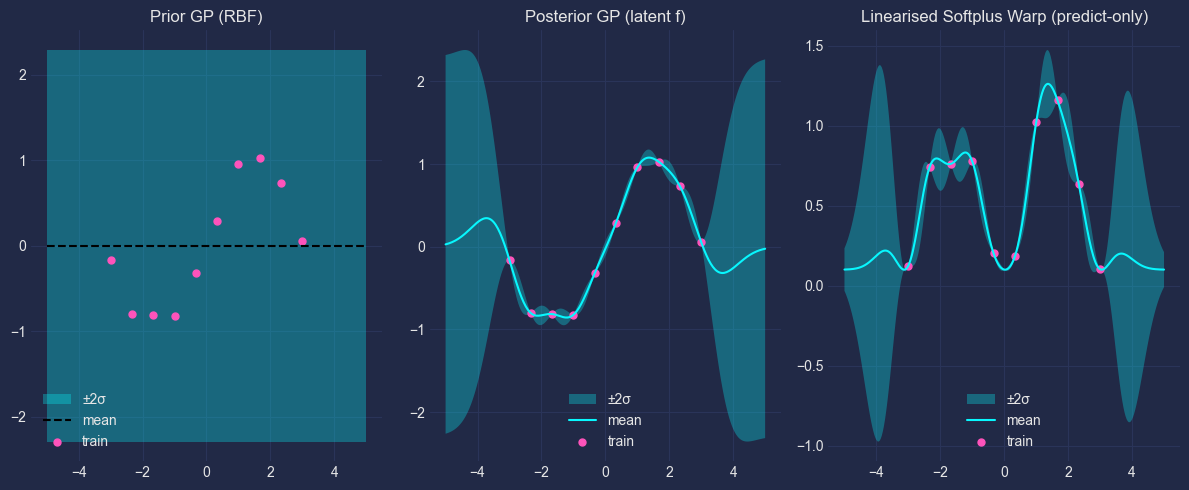

In [11]:
# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(0.1), amplitude=jnp.array(1.0))
kernel   = RBFKernel(rbf_params)
backend  = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 10).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt  = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik   = GaussianLikelihood()
model = GPModel(gp=gp, likelihood=lik)
post  = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior (unwarped) ---
m_post = post.mean(Fte)          # shape (n,1)
v_post = post.variance(Fte)      # shape (n,)

# ---------------------------------------------------------------------
# Linearised positivity warp at prediction time (Softplus)
# g(u) = softplus(u), J_g(u) computed automatically via AD
# Reference f0(x) := current posterior mean of the latent f
# ---------------------------------------------------------------------

def ref_fn(X: Array) -> Array:
    # posterior latent mean at inputs X (shape (n,1))
    return post.mean(Probe(ops=(), fnl=Eval(X)))  # (n,1)

softplus = lambda u: 0.1 + u ** 2 #jax.nn.softplus(u)  # (...,1) -> (...,1)

# jacobian=None => AD fallback via jax.jacfwd(softplus)
op_pos = Linearise(forward=softplus, jacobian=None, ref_fn=ref_fn)

# Test probe that applies the linearised warp
Fte_pos = Probe(ops=(op_pos,), fnl=Eval(Xt))

# Posterior under linearised warp (still Gaussian thanks to affine map)
m_pos = post.mean(Fte_pos)       # (n,1)
v_pos = post.variance(Fte_pos)   # (n,)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(12,5))

# Prior
plt.subplot(1,3,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, label="train")
plt.legend()

# Posterior (unwarped)
plt.subplot(1,3,2)
plt.title("Posterior GP (latent f)")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, label="train")
plt.legend()

# Posterior with linearised softplus warp
plt.subplot(1,3,3)
plt.title("Linearised Softplus Warp (predict-only)")
plt.fill_between(xplot,
                 m_pos.reshape(-1,) - 2*jnp.sqrt(v_pos),
                 m_pos.reshape(-1,) + 2*jnp.sqrt(v_pos),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, m_pos, label="mean")
plt.scatter(Xtr.squeeze(), softplus(y), s=25, label="train")
plt.legend()

plt.tight_layout()
plt.show()


## Experimental Design

Want to pick *measurement* which maximise some acquisition function:

$$ \delta^* \in \argmax_{\delta \in \mathcal{D}} A_\delta(\mathrm{f})  $$

Here, $\mathrm{Codomain}(\delta^*) = \mathbb{R}^N$.

In [ ]:
# --- Imports you already have ---
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# GaussED bits (as in your snippet)
# from gaussed.* import Euclidean, Codomain, ZeroMeanFun, RBFParams, RBFKernel, ExactBackend, ...
# from gaussed.* import GP, Probe, Eval, GaussianLikelihood, GPModel, pack_ev2mat

# --- NEW: SED imports ---
from gaussed.ed.base import (
    PosteriorState, ExpectedImprovement,
    FixedSetProposer, GreedyArgmaxPolicy,
    propose_next, GPSample, AcqContext
)

# ----------------------------
# 1) GP prior / model
# ----------------------------
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(0.), amplitude=jnp.array(1.0))
kernel   = RBFKernel(rbf_params)

backend = ExactBackend(solverfns=solver_fns)  # assume you already set 'solver_fns'
gp = GP(domain, codomain, mean, kernel, backend)

# ----------------------------
# 2) Initial data
# ----------------------------
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 10).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# Probes for plotting/predictions
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# ----------------------------
# 3) Condition initial posterior
# ----------------------------
lik = GaussianLikelihood()
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# ----------------------------
# 4) Wrap posterior as SED PosteriorState
# ----------------------------
def make_posterior_state(post_obj):
    # predict_fn(params, X) -> (mean, var)
    def predict_fn(params, X):
        F = Probe(ops=(), fnl=Eval(X))
        m = params.mean(F).reshape(-1,)
        v = params.variance(F)  # (n,)
        return m, v

    # Thompson not required for EI; keep a lightweight, candidate-wise sampler stub (unused here)
    def sample_fn(params, key_sample):
        def eval_fn(rep, X):
            P = rep["post"]
            F = Probe(ops=(), fnl=Eval(X))
            m = P.mean(F).reshape(-1,)
            v = P.variance(F)
            eps = jax.random.normal(rep["key"], shape=m.shape)
            return m + jnp.sqrt(jnp.maximum(v, 0.0)) * eps  # marginal TS (not a true path)
        rep = {"post": params, "key": key_sample}
        return GPSample(rep=rep, eval_fn=eval_fn)

    return PosteriorState(params=post_obj, predict_fn=predict_fn, sample_fn=sample_fn)

post_state = make_posterior_state(post)

# ----------------------------
# 5) Acquisition + proposer + policy
# ----------------------------
acq = ExpectedImprovement(xi=jnp.array(1e-6))     # EI for noisy setting
proposer = FixedSetProposer(Xt)                   # discrete candidate set (your grid)
policy = GreedyArgmaxPolicy(acq=acq, proposer=proposer)

# ----------------------------
# 6) BO loop (sequential SED)
# ----------------------------
def f_true(x):  # objective to maximise (unknown in practice)
    return jnp.sin(x)

T = 8  # number of BO iterations
key_bo = jax.random.PRNGKey(42)

for t in range(T):
    key_bo, kt = jax.random.split(key_bo)
    # propose next x via EI over Xt
    y_best = jnp.max(y)
    x_next, info = propose_next(policy, post_state, kt, y_best=y_best)

    # evaluate noisy observation at x_next
    key_bo, kn = jax.random.split(key_bo)
    y_next = f_true(x_next.squeeze()) + noise * jax.random.normal(kn, shape=())

    # append to dataset
    Xtr = jnp.concatenate([Xtr, x_next[None, :]], axis=0)
    y   = jnp.concatenate([y, y_next[None]], axis=0)

    # recondition posterior
    Ftr = Probe(ops=(), fnl=Eval(Xtr))
    post = model.condition(Ftr, y)
    post_state = make_posterior_state(post)

# ----------------------------
# 7) Posterior on grid (after BO)
# ----------------------------
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# Optional: acquisition values on grid (final step) for visualisation
acq_vals = acq(Xt, post_state, AcqContext(y_best=jnp.max(y)))

# ----------------------------
# 8) Plots
# ----------------------------
xplot = Xt.squeeze()

plt.figure(figsize=(12,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr[:10].squeeze(), y[:10], s=25, c="tab:red", label="initial train")  # first 10 are initial
plt.legend()

# Posterior after BO
plt.subplot(1,2,2)
plt.title("Posterior GP after BO")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="tabblue", label="all train (incl. BO)")
# (Optional) show EI (rescaled) to see where it’s large
acq_rescaled = (acq_vals - acq_vals.min()) / (acq_vals.ptp() + 1e-12)
plt.plot(xplot, acq_rescaled * 1.5 - 2.0, "k:", alpha=0.6, label="EI (scaled)")  # drawn near lower band
plt.legend()
plt.tight_layout()
plt.show()
